<a href="https://colab.research.google.com/github/TobiasC05/ITAI1378_PlantDiseaseClassificaiton_PDC/blob/main/notebooks/FP_PixelPredators_Elham_Timory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pixel Predators: 38-Class Plant Disease Classifier

This notebook follows our midterm plan more closely.

The model predicts one of the **38 PlantVillage crop-condition classes**, such as:

- `Apple___healthy`
- `Apple___Apple_scab`
- `Tomato___Early_blight`
- `Tomato___healthy`

The application also converts the predicted class into a simpler status:

- **HEALTHY**
- **DISEASED**

## System flow

**Leaf image → preprocessing → ResNet50 → exact crop-condition class → HEALTHY or DISEASED → confidence score**

This is a proof of concept and not a professional agricultural diagnosis.

In [1]:
# Install the extra libraries used by the notebook.
!pip install -q datasets gradio scikit-learn pandas matplotlib pillow tqdm

## 1. Import the libraries and choose the main settings

In [2]:
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from tqdm.auto import tqdm

# Keep random operations more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use a GPU when available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Main model settings.
IMAGE_SIZE = 224
BATCH_SIZE = 32
HEAD_EPOCHS = 3
FINETUNE_EPOCHS = 2
HEAD_LEARNING_RATE = 0.001
FINETUNE_LEARNING_RATE = 0.0001

# Use a limited number from each class for free Colab.
TRAIN_PER_CLASS = 350
VAL_PER_CLASS = 70
TEST_PER_CLASS = 90

RESULTS_DIR = Path("results")
MODELS_DIR = Path("models")
RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("Device:", device)

Device: cuda


## 2. Load PlantVillage and read the 38 class names

In [3]:
DATASET_ID = "BrandonFors/Plant-Diseases-PlantVillage-Dataset"

# Download the dataset.
dataset = load_dataset(DATASET_ID)

# Read all class names from the label feature.
CLASS_NAMES = list(
    dataset["train"].features["label"].names
)

NUM_CLASSES = len(CLASS_NAMES)

print(dataset)
print("Number of classes:", NUM_CLASSES)

for index, name in enumerate(CLASS_NAMES):
    print(index, name)

# This project expects 38 PlantVillage classes.
assert NUM_CLASSES == 38, (
    f"Expected 38 classes, but found {NUM_CLASSES}."
)

README.md:   0%|          | 0.00/6.64k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  321MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  362MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  170MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/43456 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10849 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 43456
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10849
    })
})
Number of classes: 38
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry_

## 3. Create balanced training, validation, and test sets

Each class is limited separately so larger classes do not dominate smaller ones.

In [4]:
def balanced_multiclass_sample(hf_dataset, number_per_class):
    # Store row numbers for each of the 38 classes.
    indices_by_class = {
        class_index: []
        for class_index in range(NUM_CLASSES)
    }

    for row_index, label in enumerate(hf_dataset["label"]):
        indices_by_class[int(label)].append(row_index)

    rng = random.Random(SEED)
    selected_indices = []

    # Select the same maximum number from every class.
    for class_index in range(NUM_CLASSES):
        class_indices = indices_by_class[class_index]
        rng.shuffle(class_indices)
        selected_indices.extend(
            class_indices[:number_per_class]
        )

    rng.shuffle(selected_indices)
    return hf_dataset.select(selected_indices)

# Create validation data from the original training split.
train_val = dataset["train"].train_test_split(
    test_size=0.15,
    seed=SEED,
    stratify_by_column="label",
)

train_hf = balanced_multiclass_sample(
    train_val["train"],
    TRAIN_PER_CLASS,
)

val_hf = balanced_multiclass_sample(
    train_val["test"],
    VAL_PER_CLASS,
)

test_hf = balanced_multiclass_sample(
    dataset["test"],
    TEST_PER_CLASS,
)

print("Training images:", len(train_hf))
print("Validation images:", len(val_hf))
print("Test images:", len(test_hf))

Training images: 12489
Validation images: 2452
Test images: 3269


## 4. Prepare the images for ResNet50

In [5]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Training images receive small random changes.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0),
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10,
    ),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Validation, test, and uploaded images stay consistent.
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class PlantVillageDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        item = self.data[index]

        image = item["image"].convert("RGB")
        image = self.transform(image)

        label = int(item["label"])

        return image, label

train_dataset = PlantVillageDataset(
    train_hf,
    train_transform,
)

val_dataset = PlantVillageDataset(
    val_hf,
    test_transform,
)

test_dataset = PlantVillageDataset(
    test_hf,
    test_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 391
Validation batches: 77
Test batches: 103


## 5. Look at a few training images

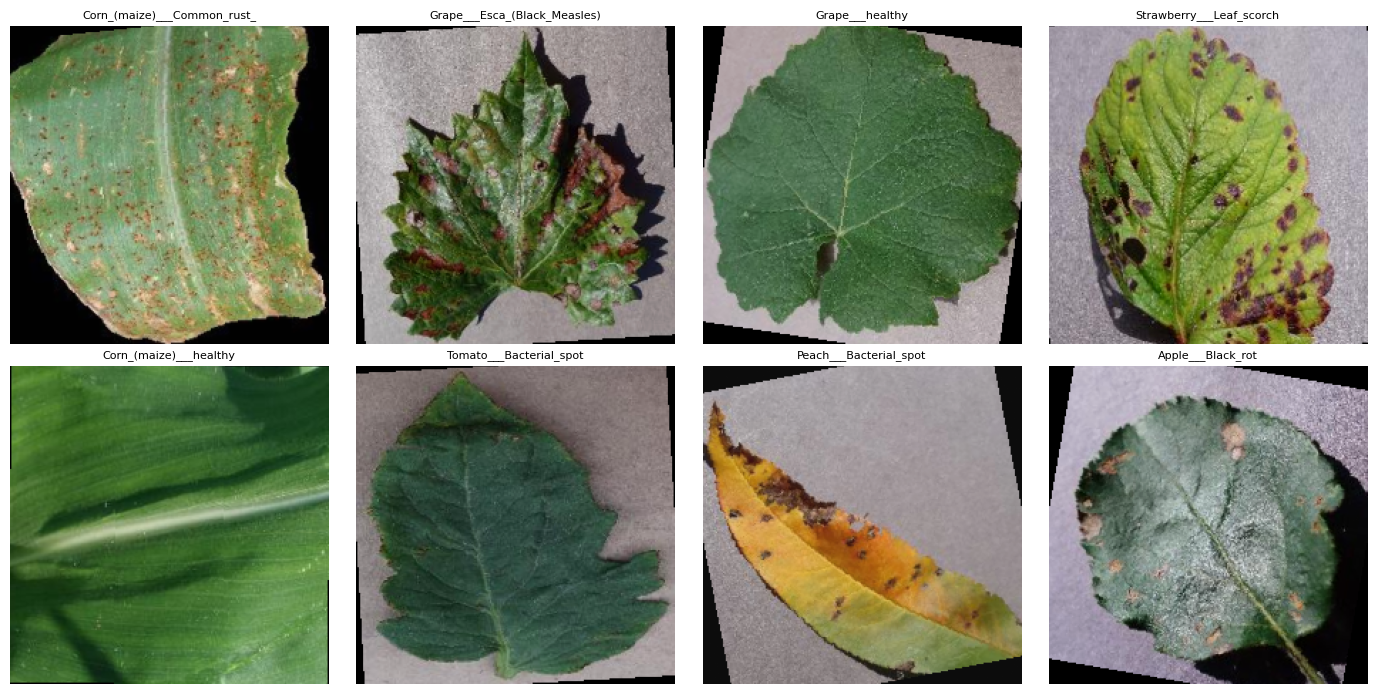

In [6]:
def show_image(tensor):
    # Reverse normalization for display.
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)

    return (
        tensor.cpu() * std + mean
    ).clamp(0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(14, 7))

for index in range(8):
    plt.subplot(2, 4, index + 1)

    plt.imshow(
        show_image(images[index]).permute(1, 2, 0)
    )

    plt.title(
        CLASS_NAMES[int(labels[index])],
        fontsize=8,
    )

    plt.axis("off")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "sample_training_images.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 6. Build a 38-output ResNet50 model

The original ResNet50 output layer is replaced with a new layer containing exactly 38 outputs.

In [7]:
# Load pretrained ResNet50.
model = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

# Freeze the original backbone for the first stage.
for parameter in model.parameters():
    parameter.requires_grad = False

input_features = model.fc.in_features

# Replace the original classifier.
model.fc = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(
        input_features,
        NUM_CLASSES,
    ),
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

print(model.fc)
print("Number of outputs:", NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 133MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=38, bias=True)
)
Number of outputs: 38


## 7. Training and validation functions

In [8]:
def run_epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train(training)

    all_true = []
    all_pred = []
    total_loss = 0.0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()

        predictions = outputs.argmax(dim=1)

        total_loss += (
            loss.item() * images.size(0)
        )

        all_true.extend(
            labels.cpu().tolist()
        )

        all_pred.extend(
            predictions.cpu().tolist()
        )

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(
            all_true,
            all_pred,
        ),
        "macro_f1": f1_score(
            all_true,
            all_pred,
            average="macro",
            zero_division=0,
        ),
    }

history = []
best_val_accuracy = 0.0

best_model_path = (
    MODELS_DIR
    / "best_plantvillage_38_class_resnet50.pth"
)

def train_stage(
    stage_name,
    epochs,
    learning_rate,
):
    global best_val_accuracy

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    optimizer = torch.optim.Adam(
        trainable_parameters,
        lr=learning_rate,
    )

    print("\nStage:", stage_name)

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(
            train_loader,
            optimizer,
        )

        val_metrics = run_epoch(
            val_loader,
        )

        history.append({
            "stage": stage_name,
            "epoch": epoch,
            "train_accuracy": train_metrics["accuracy"],
            "train_loss": train_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_macro_f1": val_metrics["macro_f1"],
        })

        print(
            f"Epoch {epoch}: "
            f"train accuracy = {train_metrics['accuracy']:.4f}, "
            f"validation accuracy = {val_metrics['accuracy']:.4f}, "
            f"validation macro F1 = {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["accuracy"] > best_val_accuracy:
            best_val_accuracy = val_metrics["accuracy"]

            torch.save({
                "model_state_dict": model.state_dict(),
                "class_names": CLASS_NAMES,
            }, best_model_path)

            print("Saved the new best model.")

## 8. Train the new 38-class output layer

In [9]:
train_stage(
    stage_name="Classifier head training",
    epochs=HEAD_EPOCHS,
    learning_rate=HEAD_LEARNING_RATE,
)


Stage: Classifier head training


  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/77 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ea5f63209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

AssertionError: can only test a child processException ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ea5f63209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 1: train accuracy = 0.7397, validation accuracy = 0.8870, validation macro F1 = 0.8847
Saved the new best model.


...

  0%|          | 0/77 [00:00<?, ?it/s]

Epoch 2: train accuracy = 0.8936, validation accuracy = 0.9168, validation macro F1 = 0.9148
Saved the new best model.


  0%|          | 0/391 [00:00<?, ?it/s]

  0%|          | 0/77 [00:00<?, ?it/s]

Epoch 3: train accuracy = 0.9156, validation accuracy = 0.9319, validation macro F1 = 0.9296
Saved the new best model.


## 9. Fine-tune the final ResNet block

This matches the midterm plan more closely. The final feature block is allowed to learn plant-specific patterns.

In [10]:
# Unfreeze the final ResNet block.
for parameter in model.layer4.parameters():
    parameter.requires_grad = True

# Keep the new classifier trainable.
for parameter in model.fc.parameters():
    parameter.requires_grad = True

train_stage(
    stage_name="Final ResNet block fine-tuning",
    epochs=FINETUNE_EPOCHS,
    learning_rate=FINETUNE_LEARNING_RATE,
)

print(
    "Best validation accuracy:",
    round(best_val_accuracy, 4),
)


Stage: Final ResNet block fine-tuning


  0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ea5f63209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ea5f63209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/77 [00:00<?, ?it/s]

Epoch 1: train accuracy = 0.9518, validation accuracy = 0.9715, validation macro F1 = 0.9714
Saved the new best model.


  0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ea5f63209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ea5f63209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/77 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ea5f63209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
          Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7ea5f63209a0>^
Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    ^if w.is_alive():^^
^ ^ ^ ^ ^ ^  ^^^^^^^^^^^^

Epoch 2: train accuracy = 0.9768, validation accuracy = 0.9829, validation macro F1 = 0.9831
Saved the new best model.
Best validation accuracy: 0.9829


## 10. Test the best model

In [11]:
checkpoint = torch.load(
    best_model_path,
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

test_true = []
test_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        test_true.extend(
            labels.tolist()
        )

        test_pred.extend(
            predictions.cpu().tolist()
        )

test_accuracy = accuracy_score(
    test_true,
    test_pred,
)

test_macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0,
)

print(
    "38-class test accuracy:",
    round(test_accuracy, 4),
)

print(
    "38-class macro F1:",
    round(test_macro_f1, 4),
)

report = classification_report(
    test_true,
    test_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(
    report
).transpose()

report_df.to_csv(
    RESULTS_DIR
    / "classification_report_38_classes.csv"
)

display(report_df)

  0%|          | 0/103 [00:00<?, ?it/s]

38-class test accuracy: 0.9771
38-class macro F1: 0.9773


,precision,recall,f1-score,support
Apple___Apple_scab,1.000000,0.977778,0.988764,90.000000
Apple___Black_rot,0.978261,1.000000,0.989011,90.000000
Apple___Cedar_apple_rust,1.000000,1.000000,1.000000,55.000000
Apple___healthy,1.000000,0.966667,0.983051,90.000000
Blueberry___healthy,0.978261,1.000000,0.989011,90.000000
Cherry_(including_sour)___Powdery_mildew,1.000000,1.000000,1.000000,90.000000
Cherry_(including_sour)___healthy,1.000000,1.000000,1.000000,90.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.933333,0.933333,0.933333,90.000000
Corn_(maize)___Common_rust_,1.000000,1.000000,1.000000,90.000000
Corn_(maize)___Northern_Leaf_Blight,0.933333,0.933333,0.933333,90.000000


## 10A. Find the worst-performing classes

This cell looks only at the 38 real PlantVillage classes.

It sorts them by F1-score from lowest to highest, shows the five weakest classes, and saves the table for the final presentation.

In [12]:
# Keep only the 38 actual PlantVillage classes.
# This removes summary rows such as accuracy, macro average, and weighted average.
class_results = report_df.loc[CLASS_NAMES].copy()

# Sort the classes from lowest to highest F1-score.
worst_classes = class_results.sort_values(
    by="f1-score",
    ascending=True,
)

# Keep the five lowest-performing classes.
worst_five = worst_classes[
    ["precision", "recall", "f1-score", "support"]
].head(5)

print("Five lowest-performing PlantVillage classes:")
display(worst_five)

# Save the table for GitHub and the results slide.
worst_five.to_csv(
    RESULTS_DIR / "worst_5_classes.csv"
)

# Save the two weakest class names separately for easy use in the presentation.
two_worst_class_names = worst_five.index[:2].tolist()

print("Two weakest classes:")
for class_name in two_worst_class_names:
    print("-", class_name)

Five lowest-performing PlantVillage classes:


,precision,recall,f1-score,support
Tomato___Early_blight,0.875000,0.933333,0.903226,90.0
Tomato___Bacterial_spot,0.987500,0.877778,0.929412,90.0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.933333,0.933333,0.933333,90.0
Corn_(maize)___Northern_Leaf_Blight,0.933333,0.933333,0.933333,90.0
Tomato___Late_blight,0.943820,0.933333,0.938547,90.0


Two weakest classes:
- Tomato___Early_blight
- Tomato___Bacterial_spot


## 11. Create the 38-class confusion matrix and training graph

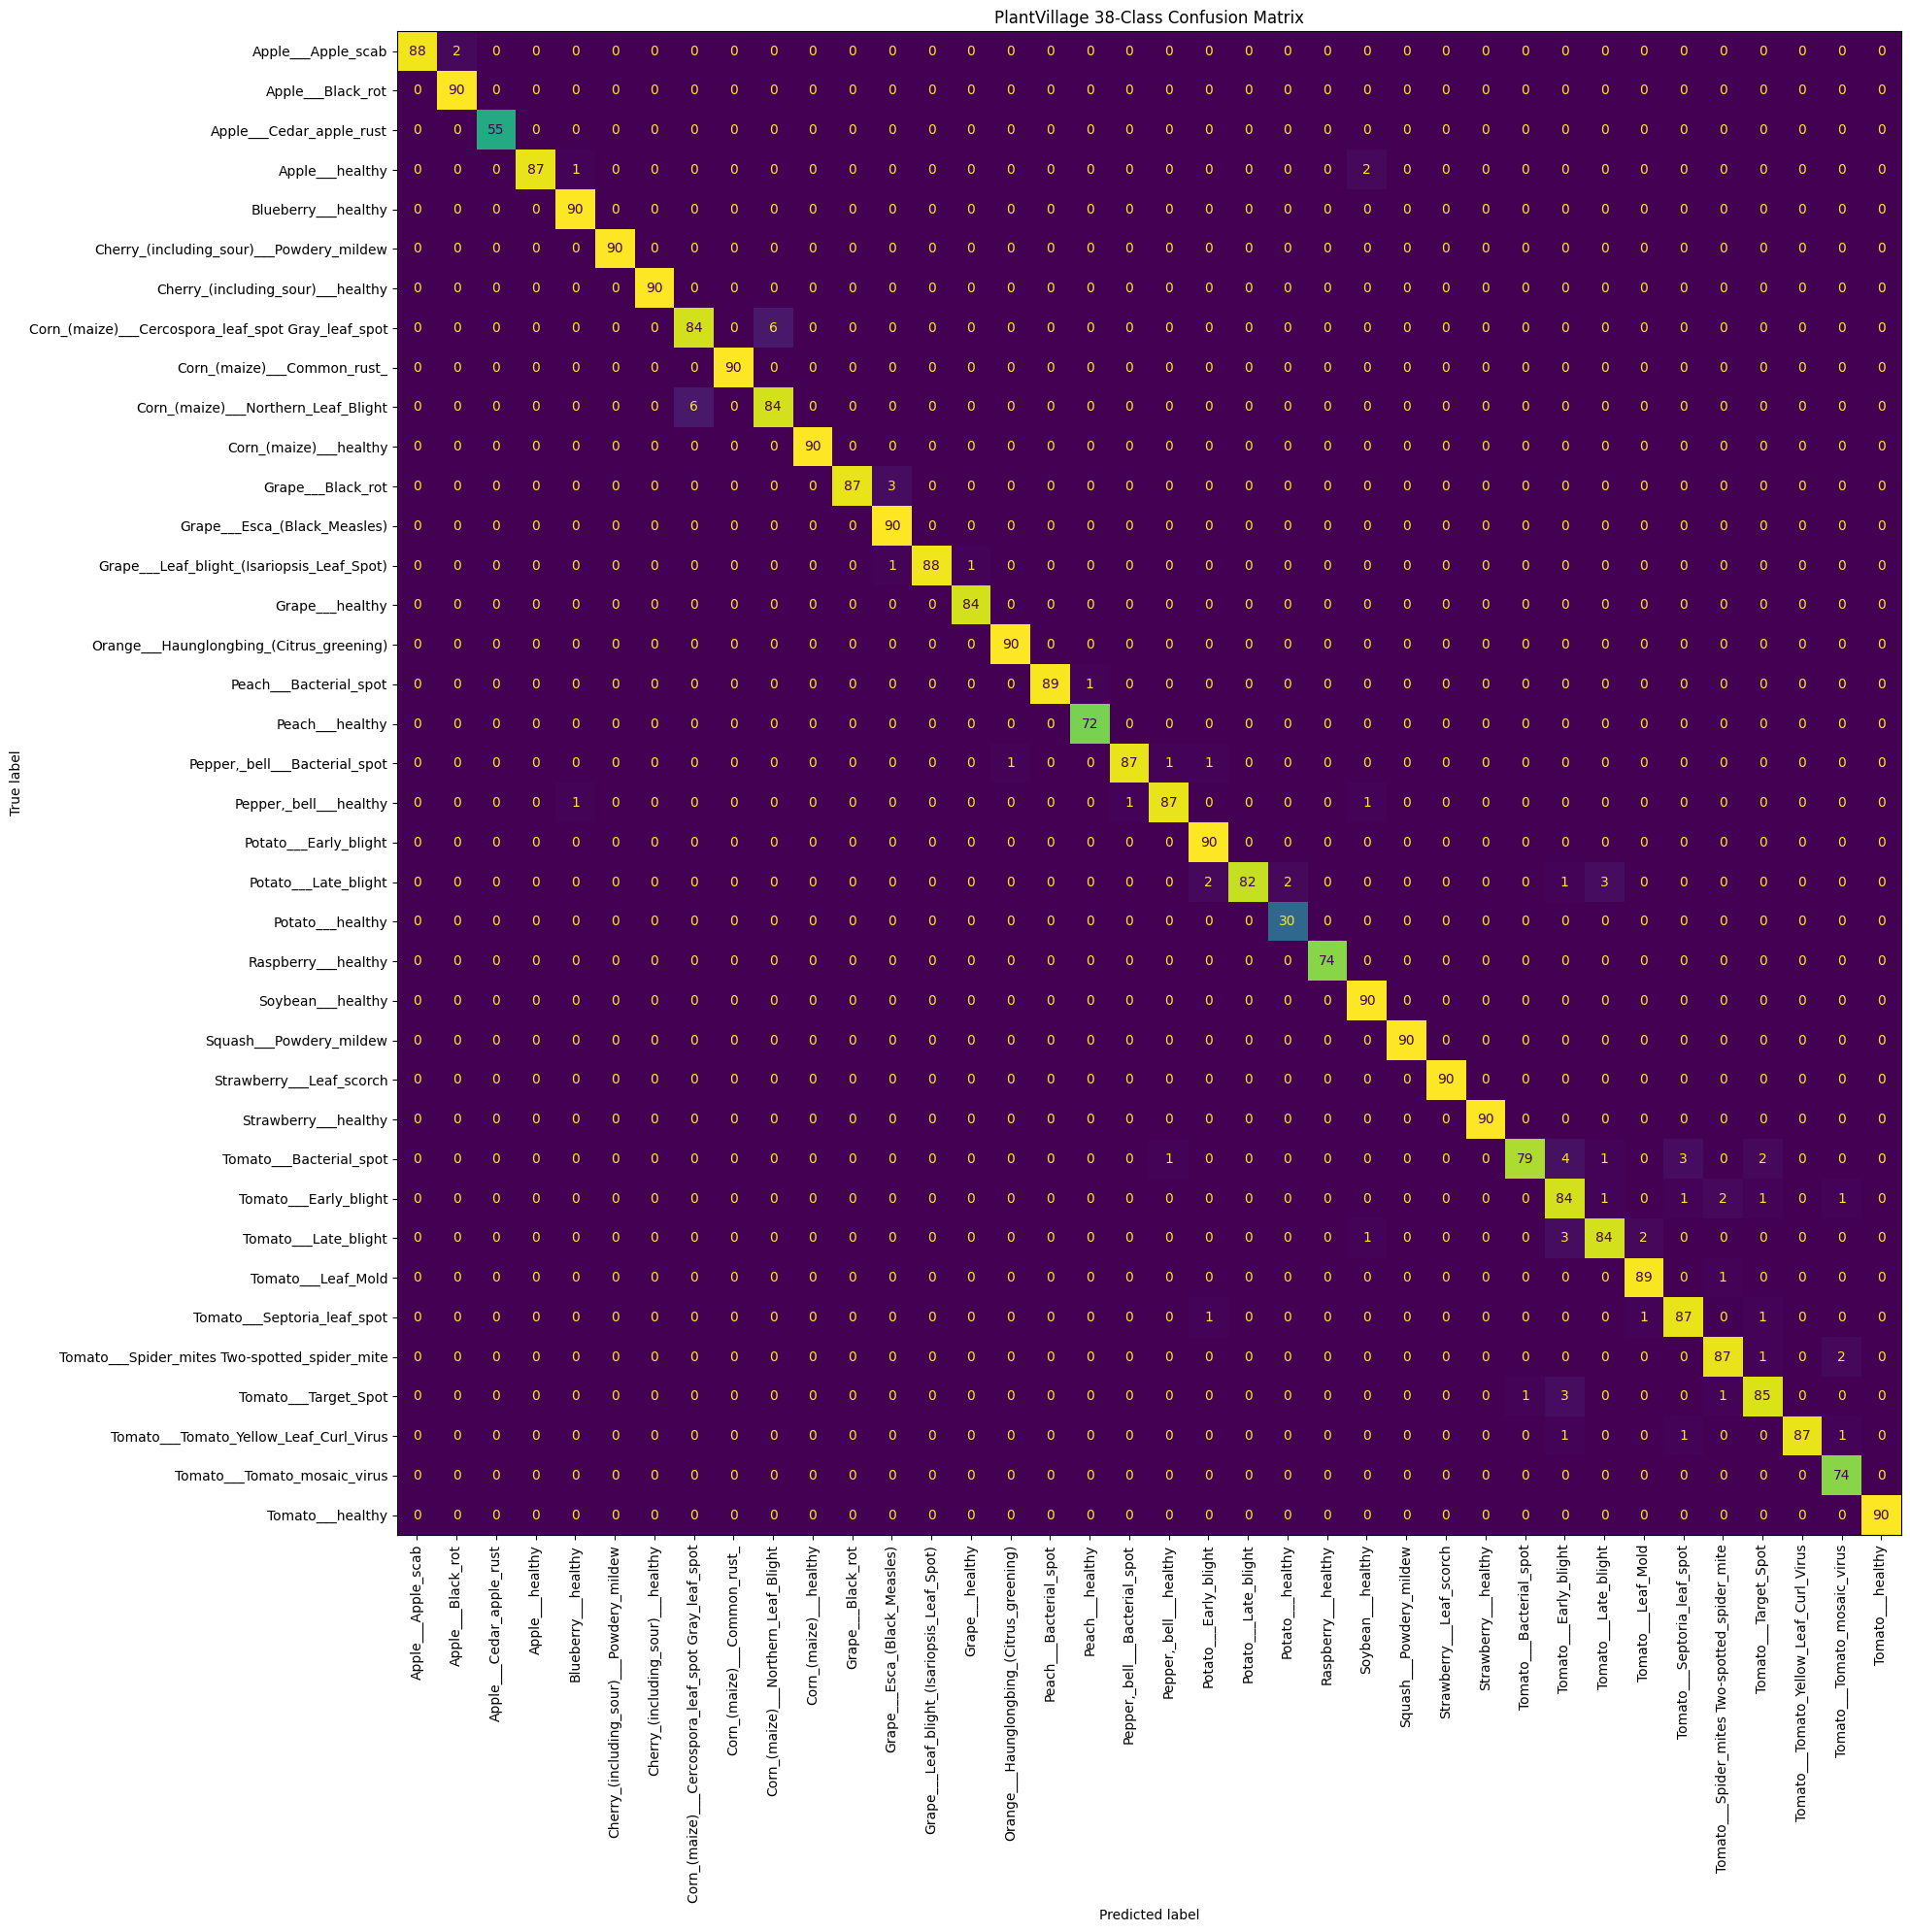

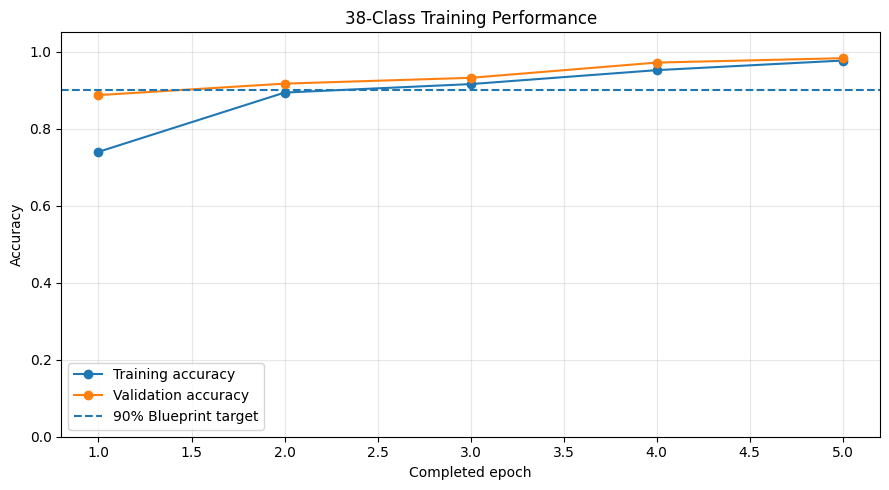

In [13]:
# Create a large confusion matrix for all 38 classes.
matrix = confusion_matrix(
    test_true,
    test_pred,
    labels=list(range(NUM_CLASSES)),
)

figure, axis = plt.subplots(
    figsize=(20, 20)
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=CLASS_NAMES,
)

display_matrix.plot(
    ax=axis,
    xticks_rotation=90,
    values_format="d",
    colorbar=False,
)

axis.set_title(
    "PlantVillage 38-Class Confusion Matrix"
)

plt.tight_layout()
plt.savefig(
    RESULTS_DIR
    / "confusion_matrix_38_classes.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# Save and plot training history.
history_df = pd.DataFrame(history)

history_df.to_csv(
    RESULTS_DIR / "training_history.csv",
    index=False,
)

plt.figure(figsize=(9, 5))

plt.plot(
    history_df.index + 1,
    history_df["train_accuracy"],
    marker="o",
    label="Training accuracy",
)

plt.plot(
    history_df.index + 1,
    history_df["val_accuracy"],
    marker="o",
    label="Validation accuracy",
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90% Blueprint target",
)

plt.xlabel("Completed epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("38-Class Training Performance")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "training_graph.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## 12. Create the one-image prediction function

The model predicts the exact crop-condition class.

The function also checks whether that predicted class is healthy or diseased.

In [14]:
def health_status_from_class(class_name):
    # Any predicted class containing "healthy" is HEALTHY.
    if "healthy" in class_name.lower():
        return "HEALTHY"

    return "DISEASED"

def predict_leaf(pil_image):
    image_tensor = test_transform(
        pil_image.convert("RGB")
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        outputs = model(image_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1,
        )[0].cpu().numpy()

    predicted_index = int(
        np.argmax(probabilities)
    )

    predicted_class = (
        CLASS_NAMES[predicted_index]
    )

    confidence = float(
        probabilities[predicted_index]
    )

    status = health_status_from_class(
        predicted_class
    )

    return (
        predicted_class,
        status,
        confidence,
        probabilities,
    )

## 13. Save a correct example and a failure case

  0%|          | 0/3269 [00:00<?, ?it/s]

Correct predictions: 3194
Failure cases: 75


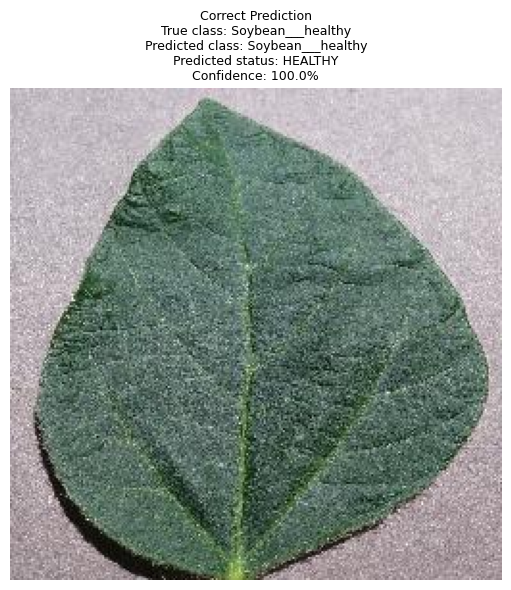

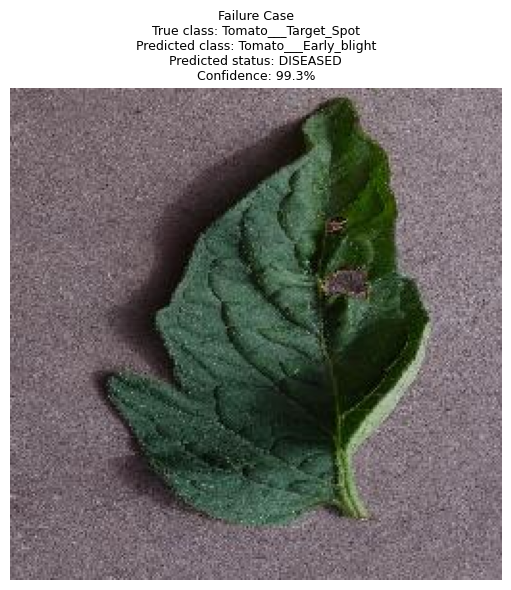

In [15]:
prediction_rows = []

for index in tqdm(range(len(test_hf))):
    item = test_hf[index]

    true_index = int(item["label"])
    true_class = CLASS_NAMES[true_index]

    (
        predicted_class,
        predicted_status,
        confidence,
        _,
    ) = predict_leaf(item["image"])

    prediction_rows.append({
        "index": index,
        "true_class": true_class,
        "true_status": health_status_from_class(true_class),
        "predicted_class": predicted_class,
        "predicted_status": predicted_status,
        "confidence": confidence,
        "correct": predicted_class == true_class,
    })

predictions_df = pd.DataFrame(
    prediction_rows
)

predictions_df.to_csv(
    RESULTS_DIR
    / "test_predictions_38_classes.csv",
    index=False,
)

correct_examples = predictions_df[
    predictions_df["correct"]
]

failure_examples = predictions_df[
    ~predictions_df["correct"]
]

print(
    "Correct predictions:",
    len(correct_examples),
)

print(
    "Failure cases:",
    len(failure_examples),
)

def show_example(
    row,
    title,
    filename,
):
    image = test_hf[
        int(row["index"])
    ]["image"]

    plt.figure(figsize=(6, 6))
    plt.imshow(image)

    plt.title(
        f"{title}\n"
        f"True class: {row['true_class']}\n"
        f"Predicted class: {row['predicted_class']}\n"
        f"Predicted status: {row['predicted_status']}\n"
        f"Confidence: {row['confidence']:.1%}",
        fontsize=9,
    )

    plt.axis("off")
    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR / filename,
        dpi=160,
        bbox_inches="tight",
    )

    plt.show()

if len(correct_examples) > 0:
    correct_row = correct_examples.sort_values(
        "confidence",
        ascending=False,
    ).iloc[0]

    show_example(
        correct_row,
        "Correct Prediction",
        "correct_prediction.png",
    )

if len(failure_examples) > 0:
    failure_row = failure_examples.sort_values(
        "confidence",
        ascending=False,
    ).iloc[0]

    show_example(
        failure_row,
        "Failure Case",
        "failure_case.png",
    )

## 14. Measure prediction speed and save the main metrics

In [16]:
# Warm up the GPU.
for index in range(5):
    predict_leaf(
        test_hf[index]["image"]
    )

if device.type == "cuda":
    torch.cuda.synchronize()

times = []

for index in range(
    min(50, len(test_hf))
):
    start = time.perf_counter()

    predict_leaf(
        test_hf[index]["image"]
    )

    if device.type == "cuda":
        torch.cuda.synchronize()

    times.append(
        time.perf_counter() - start
    )

average_prediction_time = float(
    np.mean(times)
)

metrics = {
    "number_of_classes": NUM_CLASSES,
    "test_accuracy": float(test_accuracy),
    "macro_f1": float(test_macro_f1),
    "average_prediction_seconds": average_prediction_time,
    "accuracy_target": 0.90,
    "speed_target_seconds": 1.0,
    "accuracy_target_met": bool(
        test_accuracy >= 0.90
    ),
    "speed_target_met": bool(
        average_prediction_time < 1.0
    ),
}

with open(
    RESULTS_DIR / "metrics_38_classes.json",
    "w",
) as file:
    json.dump(
        metrics,
        file,
        indent=2,
    )

print(
    "Average prediction time:",
    round(
        average_prediction_time,
        4,
    ),
    "seconds",
)

display(pd.DataFrame([
    {
        "Metric": "38-class test accuracy",
        "Target": "At least 90%",
        "Result": f"{test_accuracy:.2%}",
        "Target met": test_accuracy >= 0.90,
    },
    {
        "Metric": "Prediction speed",
        "Target": "Under 1 second",
        "Result": f"{average_prediction_time:.4f} seconds",
        "Target met": average_prediction_time < 1.0,
    },
]))

Average prediction time: 0.0154 seconds


,Metric,Target,Result,Target met
0,38-class test accuracy,At least 90%,97.71%,True
1,Prediction speed,Under 1 second,0.0154 seconds,True


## 15. Launch the Gradio application

The application shows:

- The most likely exact crop-condition classes
- The final HEALTHY or DISEASED status
- The confidence score

In [17]:
import gradio as gr

def gradio_predict(image):
    if image is None:
        return {}, ""

    (
        predicted_class,
        status,
        confidence,
        probabilities,
    ) = predict_leaf(image)

    # Show the five most likely class predictions.
    top_indices = np.argsort(
        probabilities
    )[-5:][::-1]

    top_classes = {
        CLASS_NAMES[index]:
        float(probabilities[index])
        for index in top_indices
    }

    summary = (
        f"Predicted class: {predicted_class}\n"
        f"Health status: {status}\n"
        f"Confidence: {confidence:.1%}"
    )

    return top_classes, summary

app = gr.Interface(
    fn=gradio_predict,

    inputs=gr.Image(
        type="pil",
        label="Upload a leaf image",
    ),

    outputs=[
        gr.Label(
            num_top_classes=5,
            label="Top crop-condition predictions",
        ),
        gr.Textbox(
            label="Final result",
        ),
    ],

    title=(
        "Pixel Predators: "
        "38-Class Plant Disease Classifier"
    ),

    description=(
        "Upload a clear plant leaf image. "
        "The model predicts the crop-condition class "
        "and reports whether it appears healthy or diseased."
    ),
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aa6e2f2cdc87fa8700.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 16. Export the model and results

In [18]:
import zipfile

with open(
    MODELS_DIR / "class_names_38.json",
    "w",
) as file:
    json.dump(
        CLASS_NAMES,
        file,
        indent=2,
    )

with zipfile.ZipFile(
    "PixelPredators_38_class_model_and_results.zip",
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:

    for folder in [
        RESULTS_DIR,
        MODELS_DIR,
    ]:
        for path in folder.rglob("*"):
            if path.is_file():
                archive.write(
                    path,
                    arcname=path.as_posix(),
                )

print(
    "Created "
    "PixelPredators_38_class_model_and_results.zip"
)

Created PixelPredators_38_class_model_and_results.zip


# What changed from the binary notebook

The earlier notebook predicted only HEALTHY or DISEASED.

This version predicts one of the 38 PlantVillage crop-condition classes and then converts that prediction into an overall health status.

This version matches the original midterm plan more closely.